# Code 4 v6 — Annual-Refresh Clustering + Commodity Mapping

## 📂 INPUT FILES (read from Google Drive)
| File | Source | Notes |
|------|--------|-------|
| `data_features.parquet` | Code 3 V5 | Must contain `Excess_Ret_N500_3d`; index data extended to mid-2009 (Option A) so the Dec-2010 refresh has a formation window |
| `commodities_all.csv` | Code 1d | Includes USDINR |

## 📂 OUTPUT FILES (saved to Drive + auto-downloaded to your Downloads folder)
| File | Contents |
|------|----------|
| `clusters.csv` | One row per (stock × applicable_year): cluster, counter_cluster, commodity mapping |
| `silhouette_grid.csv` | Per (refresh year × threshold 0.20–0.70): silhouette, coverage %, cluster count — used to pick the fixed `CLUSTER_THRESHOLD` |

## 🔒 Locked Methodology
| Decision | Value | Basis |
|----------|-------|-------|
| Correlation feature | `Excess_Ret_N500_3d` (all 3 stages) | Frazzini-Pedersen (2014): 3-day overlapping returns mitigate non-synchronous trading (Epps effect) while retaining effective sample size |
| Correlation type | **Spearman** (rank) | Robust to fat-tailed midcap returns |
| Formation window | **750 trading days**, bootstrap `min(available, 750)` | SE ≈ 0.064 at eff. n ≈ 250; F-P use 5y as upper bound |
| Refresh | **Annual**: formation Dec 31 of year Y → applied Jan 1 – Dec 31 of Y+1; first formation **Dec 31, 2010** | Walk-forward; no look-ahead |
| Clustering algorithm | **Hierarchical, average linkage**, cut at distance `1 − threshold` | Mantegna (1999); LĂłpez de Prado (2020); chaining structurally impossible — replaces connected-components + eviction patch |
| Threshold selection | **One fixed threshold** chosen from silhouette grid on training-period refreshes (formation ≤ Dec 2019), subject to **coverage ≥ 40%** | No per-year tuning; per-year curves kept as diagnostic |
| Significance filter | Fisher z-test, p < 0.01, eff. n = pairwise overlap ÷ 3 | Zeroes noise correlations |
| Stage 2 counter-clusters | Threshold **−0.40** unchanged | If none qualify (expected), output 'None' — documented as empirical finding |
| Stage 3 commodity mapping | \|ρ\| ≥ 0.20 **and** significant | USDINR included (hybrid) |

## Three Stages (run per refresh year)
1. **Stage 1** — Sector-aware two-tier hierarchical clustering → clusters + Rest
2. **Stage 2** — Counter-cluster assignment (C→C > C→S > S→C > S→S)
3. **Stage 3** — Stock → best commodity (max \|Spearman ρ\|, signed)

## 1. Install & Import Libraries

In [4]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'pyarrow', '-q'], check=False)

import pandas as pd
import numpy as np
import os, re, shutil, time, warnings
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from scipy import stats
from sklearn.metrics import silhouette_score, adjusted_rand_score
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("✓ Libraries ready")

✓ Libraries ready


## 2. Configuration
### 📂 Input/output manifest + all locked parameters

In [5]:
# ════════════════════════════════════════════════════════════════
# FILE PATHS — UPDATE DRIVE_FOLDER IF YOURS DIFFERS
# ════════════════════════════════════════════════════════════════
DRIVE_FOLDER = '/content/drive/MyDrive/masters'   # 👈 UPDATE if different

# ---- INPUT FILES (from Google Drive) ----
DATA_FEATURES_FILE = f'{DRIVE_FOLDER}/data_features.parquet'   # Code 3 output
COMMODITIES_FILE   = f'{DRIVE_FOLDER}/commodities_all.csv'     # Code 1d output (incl. USDINR)

# ---- OUTPUT FILES (to Drive + auto-download) ----
CLUSTERS_OUTPUT   = f'{DRIVE_FOLDER}/clusters.csv'
SILHOUETTE_OUTPUT = f'{DRIVE_FOLDER}/silhouette_grid.csv'

# ════════════════════════════════════════════════════════════════
# LOCKED METHODOLOGY PARAMETERS
# ════════════════════════════════════════════════════════════════
CORRELATION_FEATURE  = 'Excess_Ret_N500_3d'   # 3d excess returns (Frazzini-Pedersen)
RETURN_HORIZON       = 3                       # for eff-n adjustment + commodity returns
WINDOW_DAYS          = 750                     # formation window (bootstrap min(avail, 750))

FIRST_FORMATION_YEAR = 2010                    # Dec 31, 2010 → applied to 2011
LAST_FORMATION_YEAR  = 2024                    # Dec 31, 2024 → applied to 2025

# Stage 1 — clustering
CLUSTER_THRESHOLD    = 0.40   # 👈 FINALIZE after inspecting silhouette_grid.csv
MIN_CLUSTER_SIZE     = 2
THRESHOLD_GRID       = [round(0.20 + 0.05 * i, 2) for i in range(11)]  # 0.20 … 0.70
COVERAGE_FLOOR       = 40.0   # % of eligible stocks that must be clustered

# Significance / data-sufficiency
SIG_PVALUE           = 0.01
MIN_STOCK_VALID      = 250    # min valid feature days per stock in window
MIN_PAIR_OVERLAP     = 250    # min common valid days per pair
# (both auto-relaxed proportionally in short bootstrap windows)

# Stage 2 — counter-clusters
COUNTER_THRESHOLD    = -0.40  # unchanged; 'None' expected — documented finding

# Stage 3 — commodity mapping
COMMODITY_THRESHOLD  = 0.20   # min |Spearman rho|, must also be significant

print('═' * 70)
print('  CODE 4 v6 — CONFIGURATION')
print('═' * 70)
print('  INPUTS  :', DATA_FEATURES_FILE)
print('           ', COMMODITIES_FILE)
print('  OUTPUTS :', CLUSTERS_OUTPUT)
print('           ', SILHOUETTE_OUTPUT)
print('-' * 70)
print(f'  Feature            : {CORRELATION_FEATURE}  (Spearman)')
print(f'  Window             : {WINDOW_DAYS}d, bootstrap min(available, {WINDOW_DAYS})')
print(f'  Refreshes          : Dec {FIRST_FORMATION_YEAR} → Dec {LAST_FORMATION_YEAR}'
      f'  (applied {FIRST_FORMATION_YEAR+1}–{LAST_FORMATION_YEAR+1})')
print(f'  Cluster threshold  : {CLUSTER_THRESHOLD}  (grid {THRESHOLD_GRID[0]}–{THRESHOLD_GRID[-1]},'
      f' coverage floor {COVERAGE_FLOOR}%)')
print(f'  Counter threshold  : {COUNTER_THRESHOLD}')
print(f'  Commodity threshold: |{COMMODITY_THRESHOLD}| + p<{SIG_PVALUE}')
print('═' * 70)

══════════════════════════════════════════════════════════════════════
  CODE 4 v6 — CONFIGURATION
══════════════════════════════════════════════════════════════════════
  INPUTS  : /content/drive/MyDrive/masters/data_features.parquet
            /content/drive/MyDrive/masters/commodities_all.csv
  OUTPUTS : /content/drive/MyDrive/masters/clusters.csv
            /content/drive/MyDrive/masters/silhouette_grid.csv
----------------------------------------------------------------------
  Feature            : Excess_Ret_N500_3d  (Spearman)
  Window             : 750d, bootstrap min(available, 750)
  Refreshes          : Dec 2010 → Dec 2024  (applied 2011–2025)
  Cluster threshold  : 0.4  (grid 0.2–0.7, coverage floor 40.0%)
  Counter threshold  : -0.4
  Commodity threshold: |0.2| + p<0.01
══════════════════════════════════════════════════════════════════════


## 3. Mount Drive, Verify Inputs, Stage Locally

Files are copied Drive → `/content/inputs/` to avoid Drive FUSE errors on parquet.

In [6]:
from google.colab import drive
try:
    drive.flush_and_unmount()
except Exception:
    pass
drive.mount('/content/drive', force_remount=True)
print('✓ Drive mounted fresh')

print('\nVerifying input files...')
print('-' * 70)
ok = True
for label, path in [('data_features.parquet', DATA_FEATURES_FILE),
                    ('commodities_all.csv',   COMMODITIES_FILE)]:
    if os.path.exists(path):
        print(f'  ✓ {label:28s} ({os.path.getsize(path)/1024/1024:.1f} MB)')
    else:
        print(f'  ❌ {label:28s} NOT FOUND: {path}')
        ok = False
if not ok:
    raise FileNotFoundError('Missing inputs — fix paths in Section 2.')

LOCAL_DIR = '/content/inputs'
os.makedirs(LOCAL_DIR, exist_ok=True)
LOCAL_FEATURES    = f'{LOCAL_DIR}/data_features.parquet'
LOCAL_COMMODITIES = f'{LOCAL_DIR}/commodities_all.csv'

print('\nStaging Drive → local...')
for src, dst in [(DATA_FEATURES_FILE, LOCAL_FEATURES),
                 (COMMODITIES_FILE,   LOCAL_COMMODITIES)]:
    if not os.path.exists(dst):
        shutil.copy(src, dst)
    print(f'  ✓ {os.path.basename(dst):28s} ({os.path.getsize(dst)/1024/1024:.1f} MB)')
print('\n✓ Inputs staged locally')

Mounted at /content/drive
✓ Drive mounted fresh

Verifying input files...
----------------------------------------------------------------------
  ✓ data_features.parquet        (1303.9 MB)
  ✓ commodities_all.csv          (1.2 MB)

Staging Drive → local...
  ✓ data_features.parquet        (1303.9 MB)
  ✓ commodities_all.csv          (1.2 MB)

✓ Inputs staged locally


## 4. Load Stock Features (Parquet)

Validates the feature exists and that history reaches back far enough for the Dec-2010 refresh.

In [7]:
print('Loading stock features...')
df = pd.read_parquet(LOCAL_FEATURES)

rename_map = {}
for c in df.columns:
    cl = c.lower()
    if cl == 'date':                  rename_map[c] = 'date'
    elif cl in ('ticker', 'symbol'):  rename_map[c] = 'symbol'
    elif cl == 'sector':              rename_map[c] = 'sector'
df = df.rename(columns=rename_map)
df['date'] = pd.to_datetime(df['date'])

for col in ('date', 'symbol', 'sector'):
    if col not in df.columns:
        raise ValueError(f"Required column '{col}' missing")
if CORRELATION_FEATURE not in df.columns:
    avail = sorted([c for c in df.columns if 'Excess_Ret' in c])
    raise ValueError(f"'{CORRELATION_FEATURE}' not found. Available: {avail}")

print(f'  Rows   : {len(df):,}')
print(f'  Stocks : {df["symbol"].nunique():,}')
print(f'  Dates  : {df["date"].min().date()} → {df["date"].max().date()}')

# Option-A check: Dec-2010 refresh needs pre-2011 feature history
first_feat_date = df.loc[df[CORRELATION_FEATURE].notna(), 'date'].min()
print(f'  First valid {CORRELATION_FEATURE}: {first_feat_date.date()}')
if first_feat_date > pd.Timestamp('2010-07-01'):
    print('\n  ⚠ WARNING: feature history starts late — the Dec-2010 refresh will have a')
    print('    very short bootstrap window. Did you extend Code 1c indices to mid-2009')
    print('    and re-run Code 3 (Option A)? Proceeding anyway with available data.')

# Sector lookup (mode per symbol)
stock_sector = df.groupby('symbol')['sector'].agg(lambda x: x.mode().iloc[0]).to_dict()

# Single pivot of the one feature we need (date × symbol)
feature_wide = df.pivot_table(index='date', columns='symbol',
                              values=CORRELATION_FEATURE, aggfunc='first').sort_index()
print(f'\n  Feature matrix: {feature_wide.shape} (dates × stocks)')

Loading stock features...
  Rows   : 2,417,660
  Stocks : 570
  Dates  : 2007-01-02 → 2026-06-12
  First valid Excess_Ret_N500_3d: 2007-01-05

  Feature matrix: (4796, 570) (dates × stocks)


## 5. Load Commodities & Compute 3-Day Returns

In [8]:
print('Loading commodities...')
df_comm = pd.read_csv(LOCAL_COMMODITIES)
for c in ('Date', 'date'):
    if c in df_comm.columns:
        df_comm = df_comm.rename(columns={c: 'date'})
        break
df_comm['date'] = pd.to_datetime(df_comm['date'])
df_comm = df_comm.sort_values('date').reset_index(drop=True)

COMMODITY_COLS = [c for c in df_comm.columns if c != 'date']
print(f'  Rows  : {len(df_comm):,}   Dates: {df_comm["date"].min().date()} → {df_comm["date"].max().date()}')
print(f'  Commodities ({len(COMMODITY_COLS)}): {COMMODITY_COLS}')

usd = [c for c in COMMODITY_COLS if 'USDINR' in c.upper() or 'USD_INR' in c.upper()]
print(f'  USDINR: {"✓ " + str(usd) if usd else "⚠ NOT FOUND — check column name"}')

# 3-day returns, indexed by date (same horizon as stock feature)
comm_ret = pd.DataFrame({'date': df_comm['date']})
for c in COMMODITY_COLS:
    comm_ret[c] = df_comm[c].pct_change(RETURN_HORIZON) * 100
comm_ret = comm_ret.set_index('date')
print(f'\n  ✓ {RETURN_HORIZON}d commodity returns computed')

Loading commodities...
  Rows  : 5,070   Dates: 2007-01-01 → 2026-06-12
  Commodities (17): ['GOLD', 'SILVER', 'PLATINUM', 'PALLADIUM', 'COPPER', 'ALUMINIUM', 'CRUDE_OIL_WTI', 'BRENT_CRUDE', 'NATURAL_GAS', 'SUGAR', 'COTTON', 'SOYBEAN', 'WHEAT', 'CORN', 'COFFEE', 'COCOA', 'USDINR']
  USDINR: ✓ ['USDINR']

  ✓ 3d commodity returns computed


## 6. Helper Functions

- Spearman via rank-then-Pearson (fast; pairwise-complete)
- Fisher significance filter with eff. n = pairwise overlap ÷ 3
- Two-tier hierarchical clustering (within-sector → cross-sector → Rest)
- Silhouette on clustered stocks only

In [9]:
def clean(sym):
    return sym.replace('.NS', '').replace('.BO', '')

SECTOR_SHORT = {
    'Financial Services': 'FinSvc', 'Consumer Discretionary': 'ConDisc',
    'Consumer Staples': 'ConStap', 'Communication Services': 'CommSvc',
    'Fast Moving Consumer Goods': 'FMCG', 'Information Technology': 'IT',
}
def short_sector(s):
    return SECTOR_SHORT.get(s, s).replace(' ', '')

def spearman_with_filter(W, sig_p, min_pair, horizon):
    """Spearman corr (rank→Pearson, pairwise-complete) + Fisher zeroing of
    insignificant pairs. Returns (corr_filtered, overlap_counts)."""
    ranked = W.rank(axis=0)
    corr = ranked.corr()                              # pairwise-complete Pearson on ranks
    M  = W.notna().astype(float)
    ov = pd.DataFrame(M.values.T @ M.values, index=W.columns, columns=W.columns)
    eff_n = (ov / horizon).clip(lower=0)
    z  = np.arctanh(corr.clip(-0.9999, 0.9999))
    se = 1.0 / np.sqrt((eff_n - 3).clip(lower=1e-9))
    p  = 2 * (1 - stats.norm.cdf(np.abs(z / se)))
    p  = pd.DataFrame(p, index=corr.index, columns=corr.columns)
    keep = (p < sig_p) & (ov >= min_pair)
    cf = corr.where(keep, 0.0)
    cf = cf.where(ov >= min_pair, np.nan)             # insufficient overlap → unknown
    np.fill_diagonal(cf.values, 1.0)
    return cf, ov

def to_distance(corr_f):
    """Distance = 1 − corr; unknown pairs → max distance 2.0."""
    D = 1.0 - corr_f
    D = D.fillna(2.0)
    Dv = (D.values + D.values.T) / 2.0
    np.fill_diagonal(Dv, 0.0)
    return pd.DataFrame(Dv, index=corr_f.index, columns=corr_f.columns)

def hier_clusters(Dsub, cut):
    """Average-linkage fcluster labels at distance cut."""
    if len(Dsub) < 2:
        return np.ones(len(Dsub), dtype=int)
    Z = linkage(squareform(Dsub.values, checks=False), method='average')
    return fcluster(Z, t=cut, criterion='distance')

def two_tier(D, sector_map, threshold, min_size=2):
    """Within-sector then cross-sector hierarchical clustering.
    Returns (clusters: dict[temp_name → list[sym]], rest: list[sym])."""
    cut = 1.0 - threshold
    clusters, assigned = {}, set()
    for sec in sorted({sector_map.get(s, 'Unknown') for s in D.index}):
        stocks = [s for s in D.index if sector_map.get(s, 'Unknown') == sec]
        if len(stocks) < min_size:
            continue
        labels = hier_clusters(D.loc[stocks, stocks], cut)
        for lab in np.unique(labels):
            mem = [stocks[i] for i in range(len(stocks)) if labels[i] == lab]
            if len(mem) >= min_size:
                clusters[f'__SEC__{sec}__{lab}'] = mem
                assigned.update(mem)
    leftover = [s for s in D.index if s not in assigned]
    if len(leftover) >= min_size:
        labels = hier_clusters(D.loc[leftover, leftover], cut)
        for lab in np.unique(labels):
            mem = [leftover[i] for i in range(len(leftover)) if labels[i] == lab]
            if len(mem) >= min_size:
                clusters[f'__XS__{lab}'] = mem
                assigned.update(mem)
    rest = [s for s in D.index if s not in assigned]
    return clusters, rest

def silhouette_for(D, clusters):
    """Mean silhouette over clustered stocks only (Rest excluded)."""
    members, labels = [], []
    for k, (name, mem) in enumerate(clusters.items()):
        members += mem
        labels  += [k] * len(mem)
    if len(set(labels)) < 2 or len(members) <= len(set(labels)):
        return np.nan
    Dsub = D.loc[members, members].values
    return silhouette_score(Dsub, np.array(labels), metric='precomputed')

def name_clusters(clusters, corr_f, sector_map):
    """Rename temp clusters → '{Sector}-{RepStock}' using highest avg intra-corr."""
    named = {}
    for temp, mem in clusters.items():
        sub = corr_f.loc[mem, mem].replace(1.0, np.nan)
        rep = sub.mean().idxmax() if len(mem) > 1 else mem[0]
        if temp.startswith('__XS__'):
            prefix = 'CrossSector'
        else:
            secs = [sector_map.get(s, 'Unknown') for s in mem]
            prefix = short_sector(pd.Series(secs).mode().iloc[0])
        base = f'{prefix}-{clean(rep)}'
        nm, k = base, 2
        while nm in named:                      # ensure uniqueness within year
            nm = f'{base}-{k}'; k += 1
        named[nm] = mem
    return named

print('✓ Helpers defined')

✓ Helpers defined


## 7. MAIN LOOP — Annual Refreshes

For each formation date (last trading day ≤ Dec 31 of each year):
1. Slice formation window, filter eligible stocks
2. Spearman + Fisher filter → distance matrix
3. **Silhouette grid** across all 11 thresholds (diagnostic)
4. **Stage 1** clustering at `CLUSTER_THRESHOLD` + smart naming
5. **Stage 2** counter-clusters at −0.40
6. **Stage 3** commodity mapping (significant, |ρ| ≥ 0.20)

In [10]:
t0 = time.time()
all_rows, sil_rows, yearly_summary = [], [], []
clusters_by_year = {}      # applicable_year → {name: members}  (for churn diagnostic)

for fy in range(FIRST_FORMATION_YEAR, LAST_FORMATION_YEAR + 1):
    app_year = fy + 1
    cutoff = pd.Timestamp(f'{fy}-12-31')
    dates_avail = feature_wide.index[feature_wide.index <= cutoff]
    if len(dates_avail) < 200:
        print(f'⚠ Skipping formation Dec {fy}: only {len(dates_avail)} days of history')
        continue
    window_dates = dates_avail[-WINDOW_DAYS:]
    formation_date = window_dates[-1]
    Wlen = len(window_dates)

    # Proportional relaxation for short bootstrap windows
    eff_min_stock = min(MIN_STOCK_VALID, int(Wlen * 0.7))
    eff_min_pair  = min(MIN_PAIR_OVERLAP, int(Wlen * 0.5))

    W_full = feature_wide.loc[window_dates]
    valid = W_full.notna().sum()
    elig = valid[valid >= eff_min_stock].index.tolist()
    W = W_full[elig]

    print(f'\n{"═"*70}')
    print(f'  REFRESH Dec {fy}  →  applied {app_year}')
    print(f'  Window: {window_dates[0].date()} → {formation_date.date()}  '
          f'({Wlen}d{" bootstrap" if Wlen < WINDOW_DAYS else ""})')
    print(f'  Eligible stocks: {len(elig)}  '
          f'(min {eff_min_stock} valid days; pair overlap ≥ {eff_min_pair})')

    # ── Correlation + filter + distance ─────────────────────────
    corr_f, ov = spearman_with_filter(W, SIG_PVALUE, eff_min_pair, RETURN_HORIZON)
    D = to_distance(corr_f)

    # ── Silhouette grid (diagnostic, all thresholds) ────────────
    for t in THRESHOLD_GRID:
        cl_t, rest_t = two_tier(D, stock_sector, t, MIN_CLUSTER_SIZE)
        n_in = sum(len(m) for m in cl_t.values())
        sil  = silhouette_for(D, cl_t)
        sil_rows.append({'formation_year': fy, 'applicable_year': app_year,
                         'threshold': t, 'n_clusters': len(cl_t),
                         'n_clustered': n_in, 'n_eligible': len(elig),
                         'coverage_pct': 100 * n_in / max(len(elig), 1),
                         'mean_silhouette': sil})

    # ── Stage 1 at the configured fixed threshold ───────────────
    cl_raw, rest = two_tier(D, stock_sector, CLUSTER_THRESHOLD, MIN_CLUSTER_SIZE)
    clusters = name_clusters(cl_raw, corr_f, stock_sector)
    clusters_by_year[app_year] = clusters
    n_clustered = sum(len(m) for m in clusters.values())
    cov = 100 * n_clustered / max(len(elig), 1)
    print(f'  Stage 1: {len(clusters)} clusters | {n_clustered} stocks clustered '
          f'({cov:.1f}%) | Rest {len(rest)}')

    # ── Stage 2: counter-clusters (units = clusters + Rest singles) ──
    unit_ret = {nm: W[mem].mean(axis=1) for nm, mem in clusters.items()}
    for s in rest:
        unit_ret[f'_S_{s}'] = W[s]
    U = pd.DataFrame(unit_ret)
    u_corr = U.rank(axis=0).corr()

    cluster_units = [u for u in U.columns if not u.startswith('_S_')]
    stock_units   = [u for u in U.columns if u.startswith('_S_')]
    counter_map, promoted = {}, {}

    def best_neg(unit, cands):
        cands = [c for c in cands if c != unit]
        if not cands:
            return None, np.nan
        s = u_corr.loc[unit, cands]
        return (s.idxmin(), s.min()) if s.min() < COUNTER_THRESHOLD else (None, np.nan)

    for cu in cluster_units:                                   # C→C
        b, v = best_neg(cu, cluster_units)
        if b: counter_map[cu] = (b, v)
    for cu in cluster_units:                                   # C→S
        if cu in counter_map: continue
        b, v = best_neg(cu, stock_units)
        if b:
            nm = f'SingleStock_{clean(b[3:])}'
            promoted[nm] = [b[3:]]
            counter_map[cu] = (nm, v)
    for su in stock_units:                                     # S→C
        nm = f'SingleStock_{clean(su[3:])}'
        if nm in promoted: continue
        b, v = best_neg(su, cluster_units)
        if b:
            promoted[nm] = [su[3:]]
            counter_map[nm] = (b, v)
    for su in stock_units:                                     # S→S
        nm = f'SingleStock_{clean(su[3:])}'
        if nm in counter_map or nm in promoted: continue
        b, v = best_neg(su, stock_units)
        if b:
            bn = f'SingleStock_{clean(b[3:])}'
            promoted[nm] = [su[3:]]; promoted.setdefault(bn, [b[3:]])
            counter_map[nm] = (bn, v)

    n_counter = len(counter_map)
    print(f'  Stage 2: {n_counter} counter assignments at {COUNTER_THRESHOLD}'
          + ('' if n_counter else '  (none — expected; see thesis discussion)'))

    # ── Stage 3: commodity mapping (Spearman, significant, |rho|>=thr) ──
    comm_w = comm_ret.reindex(window_dates)
    ranked_W = W.rank(axis=0)
    comm_best = {}
    for c in comm_w.columns:
        col = comm_w[c]
        if col.notna().sum() < eff_min_pair:
            continue
        rc = col.rank()
        cors = ranked_W.corrwith(rc)
        ovl  = (W.notna().mul(col.notna(), axis=0)).sum()
        effn = (ovl / RETURN_HORIZON).clip(lower=0)
        z    = np.arctanh(cors.clip(-0.9999, 0.9999))
        se   = 1.0 / np.sqrt((effn - 3).clip(lower=1e-9))
        pv   = 2 * (1 - stats.norm.cdf(np.abs(z / se)))
        ok   = (cors.abs() >= COMMODITY_THRESHOLD) & (pd.Series(pv, index=cors.index) < SIG_PVALUE) \
               & (ovl >= eff_min_pair)
        for sym in cors.index[ok]:
            v = cors[sym]
            if sym not in comm_best or abs(v) > abs(comm_best[sym][1]):
                comm_best[sym] = (c, v)
    n_comm = len(comm_best)
    print(f'  Stage 3: {n_comm}/{len(elig)} stocks mapped to a commodity '
          f'({100*n_comm/max(len(elig),1):.1f}%)')

    # ── Assemble output rows for this applicable year ───────────
    final_clusters = dict(clusters)
    for nm, mem in promoted.items():
        final_clusters[nm] = mem
    promoted_syms = {s for mem in promoted.values() for s in mem}
    sym2cluster = {s: nm for nm, mem in final_clusters.items() for s in mem}

    for sym in elig:
        cl_name = sym2cluster.get(sym, 'Rest')
        mem = [m for m in final_clusters.get(cl_name, []) if m != sym]
        cl_corr = corr_f.loc[sym, mem].mean() if mem else np.nan
        cc, ccv = counter_map.get(cl_name, ('None', np.nan))
        comm, cv = comm_best.get(sym, ('None', np.nan))
        all_rows.append({
            'applicable_year': app_year, 'formation_date': formation_date.date(),
            'sector': stock_sector.get(sym, 'Unknown'), 'symbol': sym,
            'cluster': cl_name, 'counter_cluster': cc,
            'cluster_correlation': cl_corr, 'counter_cluster_correlation': ccv,
            'mapped_commodity': comm, 'commodity_correlation': cv,
            'commodity_direction': ('none' if comm == 'None'
                                    else 'positive' if cv > 0 else 'negative')})

    yearly_summary.append({'applicable_year': app_year, 'window_days': Wlen,
                           'eligible': len(elig), 'clusters': len(clusters),
                           'coverage_pct': cov, 'rest': len(rest),
                           'counters': n_counter, 'commodity_mapped': n_comm})

df_out = pd.DataFrame(all_rows)
df_sil = pd.DataFrame(sil_rows)
print(f'\n✓ All refreshes done in {time.time()-t0:.1f}s '
      f'— {df_out["applicable_year"].nunique()} years, {len(df_out):,} stock-year rows')


══════════════════════════════════════════════════════════════════════
  REFRESH Dec 2010  →  applied 2011
  Window: 2007-12-14 → 2010-12-31  (750d)
  Eligible stocks: 408  (min 250 valid days; pair overlap ≥ 250)
  Stage 1: 58 clusters | 184 stocks clustered (45.1%) | Rest 224
  Stage 2: 0 counter assignments at -0.4  (none — expected; see thesis discussion)
  Stage 3: 33/408 stocks mapped to a commodity (8.1%)

══════════════════════════════════════════════════════════════════════
  REFRESH Dec 2011  →  applied 2012
  Window: 2008-12-17 → 2011-12-30  (750d)
  Eligible stocks: 442  (min 250 valid days; pair overlap ≥ 250)
  Stage 1: 53 clusters | 152 stocks clustered (34.4%) | Rest 290
  Stage 2: 0 counter assignments at -0.4  (none — expected; see thesis discussion)
  Stage 3: 41/442 stocks mapped to a commodity (9.3%)

══════════════════════════════════════════════════════════════════════
  REFRESH Dec 2012  →  applied 2013
  Window: 2009-12-18 → 2012-12-31  (750d)
  Eligible stock

## 8. Silhouette Grid — Pick Your Fixed Threshold

Inspect the table/plots, then set `CLUSTER_THRESHOLD` in Section 2 and re-run.
Recommendation uses **training-period refreshes only** (formation ≤ Dec 2019) with the 40% coverage floor.

Mean silhouette (rows = applicable year):


threshold,0.2000,0.2500,0.3000,0.3500,0.4000,0.4500,0.5000,0.5500,0.6000,0.6500,0.7000
applicable_year,,,,,,,,,,,
2011,-0.0040,0.0240,0.0470,0.0690,0.1060,0.1570,0.2210,0.2950,0.4020,0.4720,0.4920
2012,0.0120,0.0330,0.0490,0.0830,0.1330,0.1740,0.2600,0.3340,0.4370,0.4310,0.7430
2013,0.0080,0.0330,0.0580,0.1040,0.1550,0.2040,0.2990,0.4110,0.5220,0.5540,0.6360
2014,-0.0010,0.0310,0.0540,0.0880,0.1230,0.1680,0.2730,0.3070,0.3610,0.5430,0.6000
2015,0.0320,0.0510,0.0690,0.1120,0.1460,0.2370,0.2770,0.3190,0.4000,0.4390,0.5780
2016,0.0320,0.0470,0.0720,0.1270,0.1650,0.2310,0.2550,0.3230,0.4050,0.4300,0.5920
2017,0.0200,0.0510,0.0870,0.1270,0.1650,0.1960,0.2800,0.3110,0.4100,0.4130,0.5670
2018,0.0400,0.0660,0.1010,0.1460,0.1990,0.2660,0.3240,0.3500,0.3800,0.4150,0.6190
2019,0.0300,0.0540,0.0790,0.1140,0.1560,0.2030,0.2900,0.3330,0.3770,0.5530,0.5800



Coverage % (rows = applicable year):


threshold,0.2000,0.2500,0.3000,0.3500,0.4000,0.4500,0.5000,0.5500,0.6000,0.6500,0.7000
applicable_year,,,,,,,,,,,
2011,97.3000,94.1000,82.6000,66.4000,45.1000,27.2000,15.4000,9.6000,4.9000,3.4000,2.2000
2012,95.7000,91.9000,74.4000,55.0000,34.4000,23.1000,14.0000,8.6000,3.4000,2.3000,1.1000
2013,93.7000,80.6000,58.3000,39.7000,24.9000,16.8000,10.9000,6.8000,3.5000,3.3000,1.3000
2014,93.8000,81.8000,60.5000,43.3000,29.6000,19.3000,12.9000,9.4000,5.6000,3.0000,1.7000
2015,93.7000,76.1000,55.3000,35.7000,26.7000,16.6000,12.8000,9.2000,6.5000,5.5000,2.9000
2016,92.5000,80.3000,61.2000,38.8000,26.8000,16.4000,13.3000,8.9000,6.2000,4.8000,3.1000
2017,95.8000,82.0000,59.5000,42.7000,30.0000,19.8000,13.0000,8.9000,6.5000,4.7000,3.0000
2018,93.1000,79.7000,55.6000,36.6000,22.5000,14.1000,11.0000,7.2000,5.9000,4.1000,1.3000
2019,94.2000,81.6000,63.3000,43.5000,30.7000,20.7000,12.8000,8.8000,6.5000,3.5000,2.5000



Training-period averages (formation ≤ Dec 2019):


,mean_sil,mean_cov
threshold,,
0.2000,0.0200,94.2140
0.2500,0.0450,82.4820
0.3000,0.0700,62.6310
0.3500,0.1100,44.3560
0.4000,0.1510,29.9260
0.4500,0.2050,19.6270
0.5000,0.2760,12.9500
0.5500,0.3350,8.6040
0.6000,0.4140,5.5210



  ▶ RECOMMENDED threshold (max silhouette s.t. coverage ≥ 40.0%): 0.35
    mean silhouette 0.110 | mean coverage 44.4%

  ⚠ Current CLUSTER_THRESHOLD = 0.4 ≠ recommended 0.35.
    → Set CLUSTER_THRESHOLD = 0.35 in Section 2 and RE-RUN for final outputs.


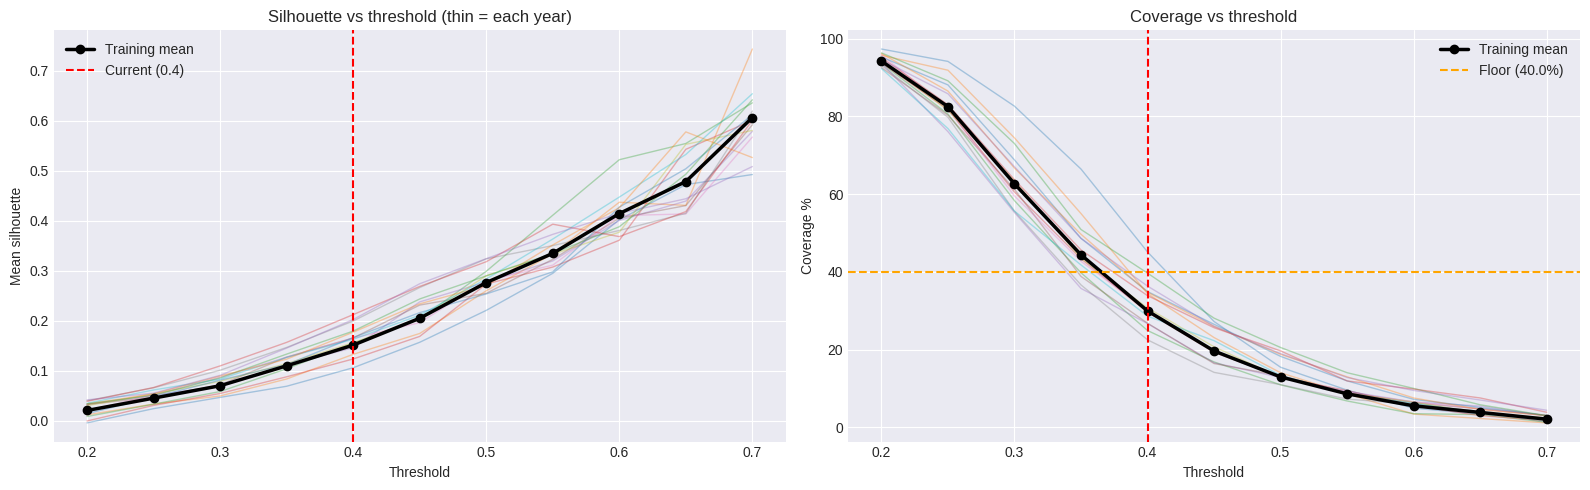

In [11]:
# Pivot tables: years × thresholds
sil_pivot = df_sil.pivot_table(index='applicable_year', columns='threshold',
                                values='mean_silhouette')
cov_pivot = df_sil.pivot_table(index='applicable_year', columns='threshold',
                                values='coverage_pct')
print('Mean silhouette (rows = applicable year):')
display(sil_pivot.round(3))
print('\nCoverage % (rows = applicable year):')
display(cov_pivot.round(1))

# Recommendation from training-period refreshes (formation_year <= 2019)
train = df_sil[df_sil['formation_year'] <= 2019]
agg = train.groupby('threshold').agg(mean_sil=('mean_silhouette', 'mean'),
                                     mean_cov=('coverage_pct', 'mean'))
cand = agg[agg['mean_cov'] >= COVERAGE_FLOOR]
print('\nTraining-period averages (formation ≤ Dec 2019):')
display(agg.round(3))
if len(cand):
    rec = cand['mean_sil'].idxmax()
    print(f'\n  ▶ RECOMMENDED threshold (max silhouette s.t. coverage ≥ {COVERAGE_FLOOR}%): {rec}')
    print(f'    mean silhouette {cand.loc[rec,"mean_sil"]:.3f} | mean coverage {cand.loc[rec,"mean_cov"]:.1f}%')
else:
    rec = None
    print(f'\n  ⚠ No threshold meets coverage ≥ {COVERAGE_FLOOR}% — inspect table, consider lower floor')
if rec is not None and abs(rec - CLUSTER_THRESHOLD) > 1e-9:
    print(f'\n  ⚠ Current CLUSTER_THRESHOLD = {CLUSTER_THRESHOLD} ≠ recommended {rec}.')
    print(f'    → Set CLUSTER_THRESHOLD = {rec} in Section 2 and RE-RUN for final outputs.')
else:
    print(f'\n  ✓ CLUSTER_THRESHOLD = {CLUSTER_THRESHOLD} matches the recommendation.')

# Plots
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for y in sil_pivot.index:
    axes[0].plot(sil_pivot.columns, sil_pivot.loc[y], alpha=0.35, lw=1)
axes[0].plot(agg.index, agg['mean_sil'], 'k-o', lw=2.5, label='Training mean')
axes[0].axvline(CLUSTER_THRESHOLD, color='red', ls='--', label=f'Current ({CLUSTER_THRESHOLD})')
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Mean silhouette')
axes[0].set_title('Silhouette vs threshold (thin = each year)'); axes[0].legend()

for y in cov_pivot.index:
    axes[1].plot(cov_pivot.columns, cov_pivot.loc[y], alpha=0.35, lw=1)
axes[1].plot(agg.index, agg['mean_cov'], 'k-o', lw=2.5, label='Training mean')
axes[1].axhline(COVERAGE_FLOOR, color='orange', ls='--', label=f'Floor ({COVERAGE_FLOOR}%)')
axes[1].axvline(CLUSTER_THRESHOLD, color='red', ls='--')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Coverage %')
axes[1].set_title('Coverage vs threshold'); axes[1].legend()
plt.tight_layout(); plt.show()

## 9. Per-Year Summary & Cluster Stability (ARI Churn)

In [12]:
df_year = pd.DataFrame(yearly_summary)
print('Per-year summary at CLUSTER_THRESHOLD =', CLUSTER_THRESHOLD)
display(df_year)

# Year-over-year membership stability: Adjusted Rand Index on stocks
# clustered (non-Rest) in BOTH consecutive years
print('\nYear-over-year cluster stability (ARI on commonly clustered stocks):')
years = sorted(clusters_by_year.keys())
ari_rows = []
for y0, y1 in zip(years[:-1], years[1:]):
    m0 = {s: nm for nm, mem in clusters_by_year[y0].items() for s in mem}
    m1 = {s: nm for nm, mem in clusters_by_year[y1].items() for s in mem}
    common = sorted(set(m0) & set(m1))
    if len(common) < 10:
        ari_rows.append({'from': y0, 'to': y1, 'common_stocks': len(common), 'ARI': np.nan})
        continue
    ari = adjusted_rand_score([m0[s] for s in common], [m1[s] for s in common])
    ari_rows.append({'from': y0, 'to': y1, 'common_stocks': len(common), 'ARI': ari})
df_ari = pd.DataFrame(ari_rows)
display(df_ari.round(3))
print('  Interpretation: ARI = 1 identical partitions; ~0 random. Moderate-high values')
print('  indicate structure persists across refreshes (thesis robustness exhibit).')

Per-year summary at CLUSTER_THRESHOLD = 0.4


,applicable_year,window_days,eligible,clusters,coverage_pct,rest,counters,commodity_mapped
0,2011,750,408,58,45.0980,224,0,33
1,2012,750,442,53,34.3891,290,0,41
2,2013,750,458,36,24.8908,344,0,27
3,2014,750,466,45,29.6137,328,0,21
4,2015,750,476,39,26.6807,349,0,13
5,2016,750,482,42,26.7635,353,0,13
6,2017,750,506,54,30.0395,354,0,7
7,2018,750,538,45,22.4907,417,0,4
8,2019,750,570,61,30.7018,395,0,8
9,2020,750,570,57,28.5965,407,0,14



Year-over-year cluster stability (ARI on commonly clustered stocks):


,from,to,common_stocks,ARI
0,2011,2012,123,0.7730
1,2012,2013,99,0.7840
2,2013,2014,101,0.8420
3,2014,2015,110,0.9100
4,2015,2016,104,0.8410
5,2016,2017,107,0.8910
6,2017,2018,107,0.8700
7,2018,2019,108,0.9020
8,2019,2020,141,0.8670
9,2020,2021,150,0.7410


  Interpretation: ARI = 1 identical partitions; ~0 random. Moderate-high values
  indicate structure persists across refreshes (thesis robustness exhibit).


## 10. Sanity Checks — Latest Year

In [13]:
latest = df_out['applicable_year'].max()
d = df_out[df_out['applicable_year'] == latest]
print(f'Sanity checks for applicable_year = {latest}')
print('=' * 70)

print('\nLargest clusters:')
display(d[d['cluster'] != 'Rest']['cluster'].value_counts().head(12))

print('\nKey-stock rows:')
for tag in ['RELIANCE', 'ONGC', 'BPCL', 'HINDALCO', 'TATASTEEL', 'INFY', 'TCS', 'HDFCBANK', 'TITAN']:
    hit = d[d['symbol'].str.contains(tag, case=False, na=False)]
    if len(hit):
        r = hit.iloc[0]
        rho = f"{r['commodity_correlation']:+.3f}" if pd.notna(r['commodity_correlation']) else '  n/a'
        print(f"  {clean(r['symbol']):14s} cluster={r['cluster']:<28s} "
              f"commodity={r['mapped_commodity']:<22s} rho={rho}")

print('\nCommodity mapping distribution (latest year):')
display(d[d['mapped_commodity'] != 'None']['mapped_commodity'].value_counts())

print('\nCounter-cluster status across ALL years:')
n_cc = (df_out['counter_cluster'] != 'None').sum()
print(f'  Assignments: {n_cc} of {len(df_out):,} stock-years at threshold {COUNTER_THRESHOLD}')
if n_cc == 0:
    print('  → Zero counter-clusters: documented as an empirical finding —')
    print('    strong negative co-movement does not exist in de-marketed Indian')
    print('    equity returns; inverse exposures are captured via Stage 3 mediation.')

Sanity checks for applicable_year = 2025

Largest clusters:


,count
cluster,
FinSvc-MAHABANK,16
Technology-INFY,10
BasicMaterials-SAIL,9
ConsumerDefensive-HINDUNILVR,7
ConsumerDefensive-RENUKA,7
BasicMaterials-RCF,6
BasicMaterials-ULTRACEMCO,5
Healthcare-SUNPHARMA,5
CommSvc-DEN,4



Key-stock rows:
  RELIANCE       cluster=Rest                         commodity=None                   rho=  n/a
  ONGC           cluster=Energy-ONGC                  commodity=None                   rho=  n/a
  BPCL           cluster=Energy-BPCL                  commodity=None                   rho=  n/a
  HINDALCO       cluster=BasicMaterials-SAIL          commodity=ALUMINIUM              rho=+0.338
  TATASTEEL      cluster=BasicMaterials-SAIL          commodity=None                   rho=  n/a
  INFY           cluster=Technology-INFY              commodity=None                   rho=  n/a
  TCS            cluster=Technology-INFY              commodity=None                   rho=  n/a
  HDFCBANK       cluster=Rest                         commodity=None                   rho=  n/a
  TITAN          cluster=Rest                         commodity=None                   rho=  n/a

Commodity mapping distribution (latest year):


,count
mapped_commodity,
BRENT_CRUDE,2
ALUMINIUM,2
COPPER,1



Counter-cluster status across ALL years:
  Assignments: 0 of 7,766 stock-years at threshold -0.4
  → Zero counter-clusters: documented as an empirical finding —
    strong negative co-movement does not exist in de-marketed Indian
    equity returns; inverse exposures are captured via Stage 3 mediation.


## 11. Validation Checks

In [14]:
print('Validation...')
print('=' * 70)
issues = []
def chk(cond, ok, bad):
    print(('  ✓  ' if cond else '  ❌ ') + (ok if cond else bad))
    if not cond: issues.append(bad)

chk(not df_out.duplicated(['symbol', 'applicable_year']).any(),
    'No duplicate (symbol, applicable_year) rows', 'Duplicate stock-year rows found')
chk(df_out['cluster'].notna().all(), 'No missing cluster assignments', 'Missing clusters')
cc = df_out['cluster_correlation'].dropna()
chk(((cc >= -1) & (cc <= 1)).all(), 'Cluster correlations in [-1,1]', 'Cluster corr out of range')
nv = df_out['counter_cluster_correlation'].dropna()
chk((nv < 0).all() if len(nv) else True,
    'Counter correlations negative (or none exist)', 'Non-negative counter correlation')
cv = df_out['commodity_correlation'].dropna()
chk(((cv >= -1) & (cv <= 1)).all(), 'Commodity correlations in [-1,1]', 'Commodity corr out of range')
chk(df_sil['threshold'].nunique() == len(THRESHOLD_GRID),
    f'Silhouette grid covers all {len(THRESHOLD_GRID)} thresholds', 'Grid incomplete')

print()
print('  ✅ All checks passed!' if not issues else f'  ⚠ {len(issues)} issue(s) — review above')

Validation...
  ✓  No duplicate (symbol, applicable_year) rows
  ✓  No missing cluster assignments
  ✓  Cluster correlations in [-1,1]
  ✓  Counter correlations negative (or none exist)
  ✓  Commodity correlations in [-1,1]
  ✓  Silhouette grid covers all 11 thresholds

  ✅ All checks passed!


## 12. Save Outputs to Drive + Auto-Download

In [15]:
df_out = df_out.sort_values(['applicable_year', 'sector', 'cluster', 'symbol']).reset_index(drop=True)
df_sil = df_sil.sort_values(['applicable_year', 'threshold']).reset_index(drop=True)

print('Saving to Google Drive...')
os.makedirs(os.path.dirname(CLUSTERS_OUTPUT), exist_ok=True)
df_out.to_csv(CLUSTERS_OUTPUT, index=False)
print(f'  ✓ {CLUSTERS_OUTPUT}  ({len(df_out):,} rows × {len(df_out.columns)} cols, '
      f'{os.path.getsize(CLUSTERS_OUTPUT)/1024:.0f} KB)')
df_sil.to_csv(SILHOUETTE_OUTPUT, index=False)
print(f'  ✓ {SILHOUETTE_OUTPUT}  ({len(df_sil):,} rows, '
      f'{os.path.getsize(SILHOUETTE_OUTPUT)/1024:.0f} KB)')

print('\nAuto-downloading to your computer (check Downloads folder)...')
from google.colab import files
for path in [CLUSTERS_OUTPUT, SILHOUETTE_OUTPUT]:
    try:
        files.download(path)
        print(f'  ✓ Downloaded {os.path.basename(path)}')
    except Exception as e:
        print(f'  ⚠ Could not auto-download {os.path.basename(path)}: {e}')

Saving to Google Drive...
  ✓ /content/drive/MyDrive/masters/clusters.csv  (7,766 rows × 11 cols, 557 KB)
  ✓ /content/drive/MyDrive/masters/silhouette_grid.csv  (165 rows, 10 KB)

Auto-downloading to your computer (check Downloads folder)...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✓ Downloaded clusters.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✓ Downloaded silhouette_grid.csv


## 13. Final Summary

In [16]:
print('═' * 70)
print('  CODE 4 v6 — COMPLETE')
print('═' * 70)
print(f'  Refresh years     : {df_out["applicable_year"].min()} → {df_out["applicable_year"].max()}')
print(f'  Stock-year rows   : {len(df_out):,}')
print(f'  Threshold used    : {CLUSTER_THRESHOLD}  '
      f'(check Section 8 recommendation; re-run if different)')
print(f'  Counter-clusters  : {(df_out["counter_cluster"] != "None").sum()} assignments')
print(f'  Commodity mapped  : {(df_out["mapped_commodity"] != "None").sum():,} stock-years')
print()
print('  Outputs:')
print(f'    {CLUSTERS_OUTPUT}')
print(f'    {SILHOUETTE_OUTPUT}')
print()
print('  Next: Code 5 — cluster & commodity features (joins on symbol + applicable_year;')
print('        backward-applied membership for long-horizon rolling features)')
print('═' * 70)

══════════════════════════════════════════════════════════════════════
  CODE 4 v6 — COMPLETE
══════════════════════════════════════════════════════════════════════
  Refresh years     : 2011 → 2025
  Stock-year rows   : 7,766
  Threshold used    : 0.4  (check Section 8 recommendation; re-run if different)
  Counter-clusters  : 0 assignments
  Commodity mapped  : 248 stock-years

  Outputs:
    /content/drive/MyDrive/masters/clusters.csv
    /content/drive/MyDrive/masters/silhouette_grid.csv

  Next: Code 5 — cluster & commodity features (joins on symbol + applicable_year;
        backward-applied membership for long-horizon rolling features)
══════════════════════════════════════════════════════════════════════
